# Cohort & Retention Analytics
**Analyst:** ELBAVIEW  
**Dataset:** E-commerce Transactions — Jan–Dec 2025  
**Last updated:** 2026-05

## 1. Business Questions

Ref: `reports/business_brief.md`

1. Monthly revenue và active customers thay đổi như thế nào?
2. Channel nào đóng góp doanh thu và khách hàng tốt nhất?
3. Retention sau tháng đầu của từng cohort ra sao?
4. Nên ưu tiên hành động gì để cải thiện retention?

---

## 2. Setup & Imports

In [1]:

# ═══════════════════════════════════════════════════════════════════════════
# Section 2: Setup & Imports
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Display options ────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.0f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

# ── Project paths ──────────────────────────────────────────────────────────
# Notebook này nằm trong notebooks/ — một subfolder của project root.
# Path.cwd()        = C:\Users\ADMIN\cohort-retention-analytics\notebooks
# Path.cwd().parent = C:\Users\ADMIN\cohort-retention-analytics  ← project root
PROJECT_DIR      = Path.cwd().parent
RAW_DIR          = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR    = PROJECT_DIR / "data" / "processed"
OUTPUT_TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_CHART_DIR = PROJECT_DIR / "outputs" / "charts"
REPORTS_DIR      = PROJECT_DIR / "reports"

for d in [PROCESSED_DIR, OUTPUT_TABLE_DIR, OUTPUT_CHART_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")
print(f"   PROJECT_DIR      : {PROJECT_DIR}")
print(f"   RAW_DIR          : {RAW_DIR}")
print(f"   PROCESSED_DIR    : {PROCESSED_DIR}")
print(f"   OUTPUT_TABLE_DIR : {OUTPUT_TABLE_DIR}")
print(f"   OUTPUT_CHART_DIR : {OUTPUT_CHART_DIR}")
print(f"   REPORTS_DIR      : {REPORTS_DIR}")
print(f"\n   RAW_DIR exists   : {RAW_DIR.exists()}")


✅ Setup complete
   PROJECT_DIR      : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics
   RAW_DIR          : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\data\raw
   PROCESSED_DIR    : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\data\processed
   OUTPUT_TABLE_DIR : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\tables
   OUTPUT_CHART_DIR : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\charts
   REPORTS_DIR      : c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\reports

   RAW_DIR exists   : True


## 3. Load Data

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 3: Load Data
# → Thêm vào project_starter.ipynb — chạy sau Section 2
# ═══════════════════════════════════════════════════════════════════════════
# ── Load 4 bảng từ data/raw/ ───────────────────────────────────────────────
customers = pd.read_csv(
    RAW_DIR / "customers.csv",
    parse_dates=["signup_date"],    # đọc signup_date là datetime64, không phải string
)

products = pd.read_csv(
    RAW_DIR / "products.csv",
    # list_price và unit_cost là integer → Pandas tự nhận dạng đúng
)

orders = pd.read_csv(
    RAW_DIR / "orders.csv",
    parse_dates=["order_date"],     # đọc order_date là datetime64
)

order_items = pd.read_csv(
    RAW_DIR / "order_items.csv",
    # tất cả cột đều là string/integer → không cần parse_dates
)

# ── Kiểm tra nhanh sau khi load ─────────────────────────────────────────────
print("✅ Loaded 4 tables:")
for name, df in [
    ("customers",   customers),
    ("products",    products),
    ("orders",      orders),
    ("order_items", order_items),
]:
    print(f"   {name:<15} → {df.shape[0]:>6,} rows  ×  {df.shape[1]} cols")

✅ Loaded 4 tables:
   customers       →    650 rows  ×  5 cols
   products        →     12 rows  ×  5 cols
   orders          →  2,057 rows  ×  6 cols
   order_items     →  5,060 rows  ×  4 cols


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 3 (tiếp): Shape, dtypes, sample — kiểm tra tất cả 4 bảng
# ═══════════════════════════════════════════════════════════════════════════

tables = {
    "customers":   customers,
    "products":    products,
    "orders":      orders,
    "order_items": order_items,
}

for tbl_name, df in tables.items():
    print(f"\n{'═'*60}")
    print(f"  📋  {tbl_name.upper()}  —  shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"{'═'*60}")
    print(df.dtypes.to_string())
    print(f"\n--- Sample (head 3) ---")
    display(df.head(3))



════════════════════════════════════════════════════════════
  📋  CUSTOMERS  —  shape: 650 rows × 5 cols
════════════════════════════════════════════════════════════
customer_id                       str
signup_date            datetime64[us]
region                            str
segment                           str
acquisition_channel               str

--- Sample (head 3) ---


,customer_id,signup_date,region,segment,acquisition_channel
0,CUST_0001,2024-07-25,TP.HCM,Regular,social_media
1,CUST_0002,2025-04-16,TP.HCM,New,social_media
2,CUST_0003,2025-12-25,Đà Nẵng,New,referral



════════════════════════════════════════════════════════════
  📋  PRODUCTS  —  shape: 12 rows × 5 cols
════════════════════════════════════════════════════════════
product_id      str
category        str
brand           str
list_price    int64
unit_cost     int64

--- Sample (head 3) ---


,product_id,category,brand,list_price,unit_cost
0,PROD_0001,Electronics,TechVN,2500000,1750000
1,PROD_0002,Electronics,TechVN,4800000,3360000
2,PROD_0003,Electronics,SmartLife,890000,622000



════════════════════════════════════════════════════════════
  📋  ORDERS  —  shape: 2,057 rows × 6 cols
════════════════════════════════════════════════════════════
order_id                    str
customer_id                 str
order_date       datetime64[us]
status                      str
gross_revenue           float64
net_revenue             float64

--- Sample (head 3) ---


,order_id,customer_id,order_date,status,gross_revenue,net_revenue
0,ORD_00001,CUST_0001,2025-07-30,completed,"8,809,000","8,809,000"
1,ORD_00002,CUST_0001,2025-09-25,completed,"8,468,000","8,468,000"
2,ORD_00003,CUST_0001,2025-09-20,completed,"3,636,000","3,636,000"



════════════════════════════════════════════════════════════
  📋  ORDER_ITEMS  —  shape: 5,060 rows × 4 cols
════════════════════════════════════════════════════════════
order_id        str
product_id      str
quantity      int64
unit_price    int64

--- Sample (head 3) ---


,order_id,product_id,quantity,unit_price
0,ORD_00001,PROD_0012,3,1113000
1,ORD_00001,PROD_0003,4,894000
2,ORD_00001,PROD_0004,2,352000


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 3 (tiếp): Key uniqueness & Referential Integrity
# Kiểm tra: primary key unique? foreign key hợp lệ?
# ═══════════════════════════════════════════════════════════════════════════

checks = {
    "customers  : customer_id  là PK duy nhất":  customers["customer_id"].nunique()  == len(customers),
    "products   : product_id   là PK duy nhất":  products["product_id"].nunique()    == len(products),
    "orders     : order_id     là PK duy nhất":  orders["order_id"].nunique()        == len(orders),
    "orders     : customer_id  → customers":     orders["customer_id"].isin(customers["customer_id"]).all(),
    "order_items: order_id     → orders":        order_items["order_id"].isin(orders["order_id"]).all(),
    "order_items: product_id   → products":      order_items["product_id"].isin(products["product_id"]).all(),
    "orders     : status chỉ 3 giá trị hợp lệ": orders["status"].isin(["completed", "cancelled", "returned"]).all(),
    "orders     : net_revenue  >= 0":            (orders["net_revenue"] >= 0).all(),
    "order_items: quantity     >= 1":            (order_items["quantity"] >= 1).all(),
    "order_items: unit_price   > 0":             (order_items["unit_price"] > 0).all(),
}

result_df = pd.DataFrame({
    "Kiểm tra": checks.keys(),
    "Kết quả":  ["✅ PASS" if v else "❌ FAIL" for v in checks.values()],
})
display(result_df.style.hide(axis="index"))

all_pass = all(checks.values())
print(f"\n{'✅ Tất cả checks đều PASS — dữ liệu hợp lệ!' if all_pass else '❌ Có check thất bại — kiểm tra lại dữ liệu!'}")


Kiểm tra,Kết quả
customers : customer_id là PK duy nhất,✅ PASS
products : product_id là PK duy nhất,✅ PASS
orders : order_id là PK duy nhất,✅ PASS
orders : customer_id → customers,✅ PASS
order_items: order_id → orders,✅ PASS
order_items: product_id → products,✅ PASS
orders : status chỉ 3 giá trị hợp lệ,✅ PASS
orders : net_revenue >= 0,✅ PASS
order_items: quantity >= 1,✅ PASS
order_items: unit_price > 0,✅ PASS



✅ Tất cả checks đều PASS — dữ liệu hợp lệ!


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 3 (tiếp): Khám phá nhanh phân phối
# Mục đích: sanity check — dữ liệu có vẻ hợp lý không?
# ═══════════════════════════════════════════════════════════════════════════

print("── Customers: phân phối theo segment ──────────────────────────")
print(customers["segment"].value_counts().to_string())

print("\n── Customers: phân phối theo acquisition_channel ──────────────")
print(customers["acquisition_channel"].value_counts().to_string())

print("\n── Orders: phân phối theo status ───────────────────────────────")
status_counts = orders["status"].value_counts()
status_pct    = (orders["status"].value_counts(normalize=True) * 100).round(1)
status_summary = pd.DataFrame({"count": status_counts, "pct (%)": status_pct})
print(status_summary.to_string())

print("\n── Orders: phân phối theo tháng (seasonality check) ───────────")
monthly_counts = (
    orders["order_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)
print(monthly_counts.to_string())

print("\n── Orders: thống kê net_revenue (chỉ completed) ────────────────")
completed = orders[orders["status"] == "completed"]["net_revenue"]
print(f"  Count   : {len(completed):,}")
print(f"  Sum     : {completed.sum():,.0f} VNĐ")
print(f"  Mean    : {completed.mean():,.0f} VNĐ")
print(f"  Median  : {completed.median():,.0f} VNĐ")
print(f"  Min     : {completed.min():,.0f} VNĐ")
print(f"  Max     : {completed.max():,.0f} VNĐ")


── Customers: phân phối theo segment ──────────────────────────
segment
New        343
Regular    217
VIP         90

── Customers: phân phối theo acquisition_channel ──────────────
acquisition_channel
paid_search     202
organic         171
social_media    137
email            77
referral         63

── Orders: phân phối theo status ───────────────────────────────
           count  pct (%)
status                   
completed   1712       83
cancelled    190        9
returned     155        8

── Orders: phân phối theo tháng (seasonality check) ───────────
order_date
2025-01     64
2025-02     51
2025-03     77
2025-04    118
2025-05    110
2025-06    152
2025-07    197
2025-08    165
2025-09    228
2025-10    235
2025-11    299
2025-12    361
Freq: M

── Orders: thống kê net_revenue (chỉ completed) ────────────────
  Count   : 1,712
  Sum     : 50,390,620,000 VNĐ
  Mean    : 29,433,773 VNĐ
  Median  : 12,487,500 VNĐ
  Min     : 268,000 VNĐ
  Max     : 473,494,000 VNĐ


## 4. Data Quality Checks

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 1: Data Quality Report
# Kiểm tra dtype, missing values, unique count cho mỗi cột của 4 bảng
# ═══════════════════════════════════════════════════════════════════════════

def build_quality_report(dataframe: pd.DataFrame, table_name: str) -> pd.DataFrame:
    """Trả về 1 dòng per cột với thông tin chất lượng cơ bản."""
    return pd.DataFrame({
        "table":         table_name,
        "column":        dataframe.columns,
        "dtype":         dataframe.dtypes.astype(str).values,
        "missing_count": dataframe.isna().sum().values,
        "missing_rate":  dataframe.isna().mean().round(4).values,
        "unique_count":  dataframe.nunique(dropna=True).values,
    })

# Áp dụng cho 4 bảng và gộp lại thành 1 DataFrame duy nhất
quality_report = pd.concat(
    [build_quality_report(df, name) for name, df in tables.items()],
    ignore_index=True,
)

# Sắp xếp: cột có missing_rate cao nhất lên trước — phát hiện vấn đề nhanh
display(
    quality_report
    .sort_values(["missing_rate", "table"], ascending=[False, True])
    .reset_index(drop=True)
    .style.hide(axis="index")
    .format({"missing_rate": "{:.2%}"})
)


table,column,dtype,missing_count,missing_rate,unique_count
customers,customer_id,str,0,0.00%,650
customers,signup_date,datetime64[us],0,0.00%,384
customers,region,str,0,0.00%,5
customers,segment,str,0,0.00%,3
customers,acquisition_channel,str,0,0.00%,5
order_items,order_id,str,0,0.00%,2057
order_items,product_id,str,0,0.00%,12
order_items,quantity,int64,0,0.00%,100
order_items,unit_price,int64,0,0.00%,1069
orders,order_id,str,0,0.00%,2057


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 2: Business Rule Validation
# Merge orders với customers → kiểm tra temporal + FK + revenue logic
# ═══════════════════════════════════════════════════════════════════════════

# ── Merge: gắn thông tin customers vào orders ─────────────────────────────
# validate="many_to_one": nhiều orders → 1 customer (1 customer có nhiều đơn)
# Nếu customers có duplicate customer_id → merge raise ValueError ngay lập tức
orders_with_customers = orders.merge(
    customers[["customer_id", "signup_date", "segment"]],
    on="customer_id",
    how="left",
    validate="many_to_one",
)

# ── Kiểm tra temporal: không thể đặt hàng trước khi đăng ký ─────────────
order_before_signup_count = (
    orders_with_customers["order_date"]
    .lt(orders_with_customers["signup_date"])
    .sum()
)

# ── Tổng hợp tất cả checks vào 1 DataFrame ───────────────────────────────
validation_checks = pd.DataFrame([
    {
        "check_name":  "missing_customer_id_orders",
        "description": "order_id không có customer_id",
        "issue_count": orders["customer_id"].isna().sum(),
    },
    {
        "check_name":  "missing_customer_profile",
        "description": "customer_id trong orders không tồn tại trong customers",
        "issue_count": orders_with_customers["signup_date"].isna().sum(),
    },
    {
        "check_name":  "order_date_before_signup",
        "description": "order_date < signup_date (không hợp lý về thời gian)",
        "issue_count": order_before_signup_count,
    },
    {
        "check_name":  "negative_net_revenue",
        "description": "net_revenue âm",
        "issue_count": orders["net_revenue"].lt(0).sum(),
    },
    {
        "check_name":  "completed_zero_revenue",
        "description": "status = completed nhưng net_revenue <= 0",
        "issue_count": orders.loc[orders["status"].eq("completed"), "net_revenue"].le(0).sum(),
    },
    {
        "check_name":  "unknown_order_product",
        "description": "product_id trong order_items không tồn tại trong products",
        "issue_count": (~order_items["product_id"].isin(products["product_id"])).sum(),
    },
])

# Gắn cờ PASS / FAIL để dễ đọc
validation_checks["status"] = validation_checks["issue_count"].apply(
    lambda n: "✅ PASS" if n == 0 else f"❌ FAIL ({n:,} issues)"
)

display(validation_checks.style.hide(axis="index"))


check_name,description,issue_count,status
missing_customer_id_orders,order_id không có customer_id,0,✅ PASS
missing_customer_profile,customer_id trong orders không tồn tại trong customers,0,✅ PASS
order_date_before_signup,order_date < signup_date (không hợp lý về thời gian),0,✅ PASS
negative_net_revenue,net_revenue âm,0,✅ PASS
completed_zero_revenue,status = completed nhưng net_revenue <= 0,0,✅ PASS
unknown_order_product,product_id trong order_items không tồn tại trong products,0,✅ PASS


## 5. Cleaning Decisions

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 3: Tạo clean_orders
# Input:  orders_with_customers (đã merge ở Phần 2)
# Output: clean_orders — DataFrame sẵn sàng cho phân tích KPI & cohort
# ═══════════════════════════════════════════════════════════════════════════

clean_orders = (
    orders_with_customers
    .drop_duplicates(subset=["order_id"])           # Loại đơn trùng key (nếu có)
    .assign(
        # Tháng đặt hàng — dùng để group theo tháng trong KPI analysis
        order_month=lambda df: df["order_date"].dt.to_period("M").dt.to_timestamp(),

        # Tháng đăng ký — dùng để xác định cohort của khách hàng
        signup_month=lambda df: df["signup_date"].dt.to_period("M").dt.to_timestamp(),

        # Boolean flag — tiện dùng trong filter và điều kiện groupby
        is_completed=lambda df: df["status"].eq("completed"),

        # Revenue dùng cho phân tích: completed → net_revenue, còn lại → 0
        # Cancelled/returned không đóng góp vào doanh thu thực tế
        analysis_revenue=lambda df: df["net_revenue"].where(
            df["status"].eq("completed"), other=0
        ),
    )
)

# ── Kiểm tra nhanh ─────────────────────────────────────────────────────────
print(f"clean_orders shape : {clean_orders.shape[0]:,} rows × {clean_orders.shape[1]} cols")
print(f"\nSample 5 dòng — 4 cột mới:")
display(clean_orders[["order_id", "status", "net_revenue", "order_month", "signup_month", "is_completed", "analysis_revenue"]].head(5))

print(f"\nPhân phối analysis_revenue theo status:")
display(
    clean_orders
    .groupby("status")["analysis_revenue"]
    .agg(so_don="count", tong_revenue="sum", trung_binh="mean")
    .reset_index()
    .style.hide(axis="index")
    .format({"tong_revenue": "{:,.0f}", "trung_binh": "{:,.0f}"})
)


clean_orders shape : 2,057 rows × 12 cols

Sample 5 dòng — 4 cột mới:


,order_id,status,net_revenue,order_month,signup_month,is_completed,analysis_revenue
0,ORD_00001,completed,"8,809,000",2025-07-01,2024-07-01,True,"8,809,000"
1,ORD_00002,completed,"8,468,000",2025-09-01,2024-07-01,True,"8,468,000"
2,ORD_00003,completed,"3,636,000",2025-09-01,2024-07-01,True,"3,636,000"
3,ORD_00004,completed,"15,360,000",2025-07-01,2024-07-01,True,"15,360,000"
4,ORD_00005,completed,"59,471,000",2025-07-01,2025-04-01,True,"59,471,000"



Phân phối analysis_revenue theo status:


status,so_don,tong_revenue,trung_binh
cancelled,190,0,0
completed,1712,"50,390,620,000","29,433,773"
returned,155,0,0


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 4: Export Quality Artifacts
# 3 file output — evidence rằng bạn đã làm data quality đúng cách
# ═══════════════════════════════════════════════════════════════════════════

# Quality artifacts → outputs/tables/ (để review, version control)
quality_report.to_csv(
    OUTPUT_TABLE_DIR / "data_quality_report.csv",
    index=False,
    encoding="utf-8-sig",   # utf-8-sig = Excel đọc được tiếng Việt
)

validation_checks.to_csv(
    OUTPUT_TABLE_DIR / "validation_checks.csv",
    index=False,
    encoding="utf-8-sig",
)

# Clean dataset → data/processed/ (dùng trực tiếp cho Buổi 5)
clean_orders.to_csv(
    PROCESSED_DIR / "clean_orders.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ Exported successfully:")
print(f"   {OUTPUT_TABLE_DIR / 'data_quality_report.csv'}")
print(f"   {OUTPUT_TABLE_DIR / 'validation_checks.csv'}")
print(f"   {PROCESSED_DIR    / 'clean_orders.csv'}")
print(f"\n   quality_report : {quality_report.shape[0]} rows  (1 row per column per table)")
print(f"   validation_checks: {validation_checks.shape[0]} checks")
print(f"   clean_orders   : {clean_orders.shape[0]:,} rows × {clean_orders.shape[1]} cols")


✅ Exported successfully:


   c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\tables\data_quality_report.csv
   c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\tables\validation_checks.csv
   c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\data\processed\clean_orders.csv

   quality_report : 20 rows  (1 row per column per table)
   validation_checks: 6 checks
   clean_orders   : 2,057 rows × 12 cols


| # | Issue phát hiện | Quyết định xử lý | Lý do |
|:-:|----------------|-----------------|-------|
| 1 | `status = cancelled` | Giữ dòng, `analysis_revenue = 0` | Cần volume để phân tích tỷ lệ huỷ; không tính vào doanh thu |
| 2 | `status = returned` | Giữ dòng, `analysis_revenue = 0` | Hoàn hàng phản ánh hành vi khách hàng; không đóng góp doanh thu ròng |
| 3 | Duplicate `order_id` | Drop duplicate, giữ dòng đầu tiên | Tránh double-count doanh thu và số đơn hàng |
| 4 | `acquisition_channel` missing | Fill `"unknown"` nếu có missing | Không xoá khách hàng hợp lệ chỉ vì thiếu channel; group riêng trong phân tích |
| 5 | `order_date < signup_date` | Flag để review — không tự động xoá | Xoá âm thầm có thể ảnh hưởng cohort; cần xác nhận nguyên nhân trước |

In [10]:
# ✅ Check 1: cancelled và returned phải có analysis_revenue = 0
clean_orders.groupby("status")["analysis_revenue"].sum()
# → cancelled = 0, returned = 0, completed > 0

status
cancelled                0
completed   50,390,620,000
returned                 0
Name: analysis_revenue, dtype: float64

In [11]:
# ✅ Check 2: order_month range hợp lý
clean_orders["order_month"].agg(["min", "max"])
# → min = 2025-01-01, max = 2025-12-01

min   2025-01-01
max   2025-12-01
Name: order_month, dtype: datetime64[us]

In [12]:
# ✅ Check 3: signup_month không sau order_month (temporal integrity)
(clean_orders["signup_month"] > clean_orders["order_month"]).sum()
# → phải = 0

np.int64(0)

In [13]:
# ✅ Check 4: 3 file output đã tồn tại trên ổ cứng
for f in [OUTPUT_TABLE_DIR / "data_quality_report.csv",
          OUTPUT_TABLE_DIR / "validation_checks.csv",
          PROCESSED_DIR    / "clean_orders.csv"]:
    print(f"{'✅' if f.exists() else '❌'} {f.name}")

✅ data_quality_report.csv
✅ validation_checks.csv
✅ clean_orders.csv


## 6. KPI Analysis



In [14]:
# Phần 0 : Load clean_orders + bổ sung acquisition_channel
# ═══════════════════════════════════════════════════════════════════════════

clean_orders = pd.read_csv(
    PROCESSED_DIR / "clean_orders.csv",
    parse_dates=["order_date", "signup_date", "order_month", "signup_month"],
)

# acquisition_channel cần cho channel_contribution ở Phần 2
# Nếu chưa có trong clean_orders → merge thêm từ customers.csv
if "acquisition_channel" not in clean_orders.columns:
    customers = pd.read_csv(RAW_DIR / "customers.csv")
    clean_orders = clean_orders.merge(
        customers[["customer_id", "acquisition_channel"]],
        on="customer_id",
        how="left",
    )
    print("ℹ️  Đã thêm cột acquisition_channel từ customers.csv")

print(f"✅ clean_orders: {clean_orders.shape[0]:,} rows × {clean_orders.shape[1]} cols")
print(f"\nCác cột: {list(clean_orders.columns)}")
print(f"\nPhân phối status:")
print(clean_orders["status"].value_counts().to_string())

ℹ️  Đã thêm cột acquisition_channel từ customers.csv
✅ clean_orders: 2,057 rows × 13 cols

Các cột: ['order_id', 'customer_id', 'order_date', 'status', 'gross_revenue', 'net_revenue', 'signup_date', 'segment', 'order_month', 'signup_month', 'is_completed', 'analysis_revenue', 'acquisition_channel']

Phân phối status:
status
completed    1712
cancelled     190
returned      155


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 1: Monthly KPI
# → Copy vào Section 6: KPI Analysis của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

monthly_kpi = (
    clean_orders
    .groupby("order_month")
    .agg(
        revenue          =("analysis_revenue", "sum"),
        orders           =("order_id",         "nunique"),
        active_customers =("customer_id",      "nunique"),
    )
    .assign(
        aov                  =lambda t: t["revenue"] / t["orders"],
        revenue_per_customer =lambda t: t["revenue"] / t["active_customers"],
        revenue_growth       =lambda t: t["revenue"].pct_change(),
    )
    .reset_index()
)

display(
    monthly_kpi
    .style.hide(axis="index")
    .format({
        "order_month":          lambda d: d.strftime("%Y-%m"),
        "revenue":              "{:,.0f}",
        "aov":                  "{:,.0f}",
        "revenue_per_customer": "{:,.0f}",
        "revenue_growth":       "{:+.1%}",
    })
)


order_month,revenue,orders,active_customers,aov,revenue_per_customer,revenue_growth
2025-01,"1,660,247,000",64,54,"25,941,359","30,745,315",+nan%
2025-02,"933,928,000",51,43,"18,312,314","21,719,256",-43.7%
2025-03,"2,136,600,000",77,64,"27,748,052","33,384,375",+128.8%
2025-04,"4,058,062,000",118,97,"34,390,356","41,835,691",+89.9%
2025-05,"2,810,456,000",110,85,"25,549,600","33,064,188",-30.7%
2025-06,"3,746,202,000",152,120,"24,646,066","31,218,350",+33.3%
2025-07,"4,947,038,000",197,140,"25,111,868","35,335,986",+32.1%
2025-08,"4,142,565,000",165,124,"25,106,455","33,407,782",-16.3%
2025-09,"6,251,772,000",228,145,"27,420,053","43,115,669",+50.9%
2025-10,"4,768,284,000",235,158,"20,290,570","30,179,013",-23.7%


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 2: Channel Contribution
# → Copy vào Section 6: KPI Analysis của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

channel_contribution = (
    clean_orders
    .loc[clean_orders["is_completed"]]          # Chỉ lấy đơn completed
    .groupby("acquisition_channel", observed=True)
    .agg(
        revenue  =("analysis_revenue", "sum"),
        orders   =("order_id",         "nunique"),
        customers=("customer_id",      "nunique"),
    )
    .assign(
        aov           =lambda t: t["revenue"] / t["orders"],
        revenue_share =lambda t: t["revenue"] / t["revenue"].sum(),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

display(
    channel_contribution
    .style.hide(axis="index")
    .format({
        "revenue":       "{:,.0f}",
        "aov":           "{:,.0f}",
        "revenue_share": "{:.1%}",
    })
)


acquisition_channel,revenue,orders,customers,aov,revenue_share
paid_search,"14,774,946,000",549,189,"26,912,470",29.3%
social_media,"13,804,152,000",358,132,"38,559,084",27.4%
organic,"10,205,171,000",374,160,"27,286,553",20.3%
email,"7,181,033,000",247,73,"29,073,008",14.3%
referral,"4,425,318,000",184,59,"24,050,641",8.8%


## 7. Cohort Retention Analysis

In [17]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 3: First Purchase Cohort
# → Copy vào Section 7: Cohort Retention Analysis của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

# Bước 1: Chỉ phân tích cohort trên đơn completed
# (cancelled/returned không phản ánh hành vi mua hàng thực sự)
completed_orders = clean_orders.loc[clean_orders["is_completed"]].copy()

# Bước 2: Tháng mua hàng đầu tiên của mỗi khách hàng
# groupby customer_id → lấy order_month nhỏ nhất (= sớm nhất)
first_purchase = (
    completed_orders
    .groupby("customer_id")
    .agg(first_purchase_month=("order_month", "min"))
    .reset_index()
)

# Bước 3: Gắn first_purchase_month vào mỗi dòng đơn hàng
# validate="many_to_one": nhiều đơn → 1 khách (1 khách có 1 first_purchase_month duy nhất)
orders_cohort = completed_orders.merge(
    first_purchase,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

print(f"✅ orders_cohort: {orders_cohort.shape[0]:,} rows × {orders_cohort.shape[1]} cols")
print(f"\nSample — xem first_purchase_month đã được gắn đúng:")
display(
    orders_cohort[["customer_id", "order_month", "first_purchase_month"]]
    .drop_duplicates(subset=["customer_id"])
    .head(5)
)


✅ orders_cohort: 1,712 rows × 14 cols

Sample — xem first_purchase_month đã được gắn đúng:


,customer_id,order_month,first_purchase_month
0,CUST_0001,2025-07-01,2025-07-01
4,CUST_0002,2025-07-01,2025-07-01
5,CUST_0003,2025-12-01,2025-12-01
6,CUST_0004,2025-11-01,2025-08-01
9,CUST_0006,2025-12-01,2025-12-01


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 4: Cohort Index
# → Copy vào Section 7 của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

orders_cohort = orders_cohort.assign(
    cohort_index=(
        (orders_cohort["order_month"].dt.year  - orders_cohort["first_purchase_month"].dt.year)  * 12
      + (orders_cohort["order_month"].dt.month - orders_cohort["first_purchase_month"].dt.month)
    )
)

print("✅ cohort_index tính xong")
print(f"\nPhân phối cohort_index (số tháng sau lần mua đầu):")
print(orders_cohort["cohort_index"].value_counts().sort_index().to_string())

print(f"\nSanity check — cohort_index tại tháng mua đầu phải = 0:")
check = orders_cohort.loc[
    orders_cohort["order_month"] == orders_cohort["first_purchase_month"],
    "cohort_index"
].eq(0).all()
print(f"   order_month == first_purchase_month → cohort_index = 0: {'✅' if check else '❌'}")


✅ cohort_index tính xong

Phân phối cohort_index (số tháng sau lần mua đầu):
cohort_index
0     918
1     156
2     112
3     110
4      71
5      63
6      88
7      51
8      58
9      39
10     35
11     11

Sanity check — cohort_index tại tháng mua đầu phải = 0:
   order_month == first_purchase_month → cohort_index = 0: ✅


In [19]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 5: Retention Matrix
# → Copy vào Section 7 của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

# ── Bước 1: Đếm unique customers mỗi (cohort, index) ─────────────────────
cohort_counts = (
    orders_cohort
    .groupby(["first_purchase_month", "cohort_index"])
    .agg(active_customers=("customer_id", "nunique"))
    .reset_index()
)

# ── Bước 2: Lấy cohort_size = số khách tại index 0 ───────────────────────
# cohort_size dùng để tính % sau này
cohort_size = (
    cohort_counts
    .loc[cohort_counts["cohort_index"].eq(0),
         ["first_purchase_month", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)

# ── Bước 3: Tính retention_rate và pivot thành matrix ────────────────────
retention = (
    cohort_counts
    .merge(cohort_size, on="first_purchase_month", how="left")
    .assign(retention_rate=lambda t: t["active_customers"] / t["cohort_size"])
)

retention_matrix = retention.pivot_table(
    index="first_purchase_month",
    columns="cohort_index",
    values="retention_rate",
)

# Format hiển thị — mỗi ô là % với 1 chữ số thập phân
display(
    retention_matrix
    .style
    .format("{:.0%}", na_rep="—")
    .background_gradient(cmap="YlGn", axis=None, low=0.1)
)


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2025-01-01 00:00:00,100%,8%,12%,21%,17%,27%,25%,27%,31%,17%,33%,21%
2025-02-01 00:00:00,100%,25%,28%,14%,22%,8%,25%,19%,19%,25%,28%,—
2025-03-01 00:00:00,100%,16%,23%,12%,30%,12%,21%,16%,19%,40%,—,—
2025-04-01 00:00:00,100%,20%,20%,27%,9%,16%,20%,16%,35%,—,—,—
2025-05-01 00:00:00,100%,14%,23%,16%,7%,9%,37%,12%,—,—,—,—
2025-06-01 00:00:00,100%,37%,11%,14%,10%,13%,22%,—,—,—,—,—
2025-07-01 00:00:00,100%,15%,13%,24%,20%,28%,—,—,—,—,—,—
2025-08-01 00:00:00,100%,28%,16%,32%,18%,—,—,—,—,—,—,—
2025-09-01 00:00:00,100%,16%,29%,29%,—,—,—,—,—,—,—,—


In [20]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 6: Revenue Cohort Matrix
# → Copy vào Section 7 của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

cohort_revenue = (
    orders_cohort
    .groupby(["first_purchase_month", "cohort_index"])
    .agg(revenue=("analysis_revenue", "sum"))
    .reset_index()
)

cohort_revenue_matrix = cohort_revenue.pivot_table(
    index="first_purchase_month",
    columns="cohort_index",
    values="revenue",
    fill_value=0,           # Tháng không có giao dịch → 0 thay vì NaN
)

display(
    cohort_revenue_matrix
    .style
    .format("{:,.0f}", na_rep="—")
    .background_gradient(cmap="Blues", axis=None)
)


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2025-01-01 00:00:00,"1,660,247,000","72,708,000","336,527,000","129,319,000","566,488,000","635,866,000","459,095,000","222,442,000","927,753,000","128,670,000","653,203,000","278,319,000"
2025-02-01 00:00:00,"861,220,000","301,094,000","499,023,000","28,044,000","181,371,000","187,618,000","211,813,000","392,356,000","256,219,000","202,944,000","286,022,000",0
2025-03-01 00:00:00,"1,498,979,000","236,500,000","209,273,000","156,692,000","425,121,000","135,304,000","252,824,000","138,008,000","489,486,000","650,206,000",0,0
2025-04-01 00:00:00,"3,193,220,000","205,718,000","667,008,000","476,474,000","301,653,000","323,378,000","477,509,000","521,237,000","624,628,000",0,0,0
2025-05-01 00:00:00,"1,800,933,000","138,154,000","289,196,000","186,892,000","83,124,000","113,092,000","187,386,000","169,738,000",0,0,0,0
2025-06-01 00:00:00,"1,967,111,000","962,473,000","118,149,000","539,516,000","196,303,000","594,286,000","363,754,000",0,0,0,0,0
2025-07-01 00:00:00,"2,147,061,000","209,656,000","84,411,000","233,686,000","184,194,000","436,169,000",0,0,0,0,0,0
2025-08-01 00:00:00,"2,756,656,000","545,920,000","318,204,000","571,389,000","438,097,000",0,0,0,0,0,0,0
2025-09-01 00:00:00,"3,102,490,000","411,582,000","557,764,000","392,298,000",0,0,0,0,0,0,0,0


## 8. Visualization

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# Step 2: Load 4 bảng từ outputs/tables/
# ═══════════════════════════════════════════════════════════════════════════

monthly_kpi = pd.read_csv(
    OUTPUT_TABLE_DIR / "monthly_kpi.csv",
    parse_dates=["order_month"],
)

channel_contribution = pd.read_csv(
    OUTPUT_TABLE_DIR / "channel_contribution.csv",
)

# Retention matrix có index là first_purchase_month → chỉ định index_col=0
retention_matrix = pd.read_csv(
    OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv",
    index_col=0,
)
# Chuyển tên cột về số nguyên (CSV lưu là string "0", "1", ...)
retention_matrix.columns = retention_matrix.columns.astype(int)

cohort_revenue_matrix = pd.read_csv(
    OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv",
    index_col=0,
)
cohort_revenue_matrix.columns = cohort_revenue_matrix.columns.astype(int)

print("✅ Load thành công:")
print(f"   monthly_kpi          : {monthly_kpi.shape[0]} tháng × {monthly_kpi.shape[1]} cột")
print(f"   channel_contribution : {channel_contribution.shape[0]} kênh × {channel_contribution.shape[1]} cột")
print(f"   retention_matrix     : {retention_matrix.shape[0]} cohort × {retention_matrix.shape[1]} index")
print(f"   cohort_revenue_matrix: {cohort_revenue_matrix.shape[0]} cohort × {cohort_revenue_matrix.shape[1]} index")


✅ Load thành công:
   monthly_kpi          : 12 tháng × 7 cột
   channel_contribution : 5 kênh × 6 cột
   retention_matrix     : 12 cohort × 12 index
   cohort_revenue_matrix: 12 cohort × 12 index


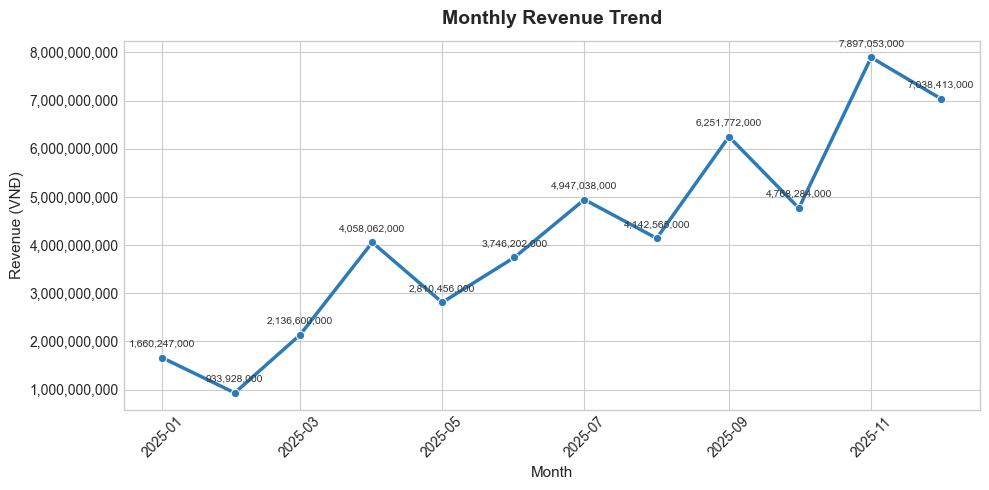

✅ Saved: c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\charts\monthly_revenue_trend.png


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# Chart 1: Monthly Revenue Trend
# → Copy vào Section 8: Visualization của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as mticker

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_kpi,
    x="order_month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#2c7bb6",
    ax=axis,
)

# Thêm nhãn số trên mỗi điểm để dễ đọc
for _, row in monthly_kpi.iterrows():
    axis.annotate(
        f"{row['revenue']:,.0f}",
        xy=(row["order_month"], row["revenue"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=7.5,
        color="#333333",
    )

axis.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=12)
axis.set_xlabel("Month", fontsize=11)
axis.set_ylabel("Revenue (VNĐ)", fontsize=11)
axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "monthly_revenue_trend.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'monthly_revenue_trend.png'}")


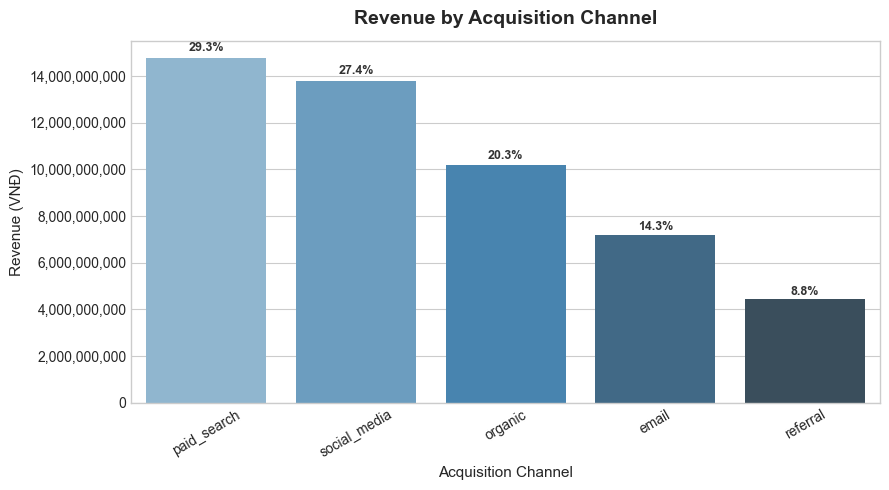

✅ Saved: c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\charts\revenue_by_channel.png


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# Chart 2: Revenue by Acquisition Channel
# → Copy vào Section 8: Visualization của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as mticker

fig, axis = plt.subplots(figsize=(9, 5))

# Sắp xếp theo revenue giảm dần trước khi vẽ
df_chart = channel_contribution.sort_values("revenue", ascending=False)

bars = sns.barplot(
    data=df_chart,
    x="acquisition_channel",
    y="revenue",
    hue="acquisition_channel",  # Đổi màu mỗi cột (cần hue từ seaborn ≥ 0.13)
    palette="Blues_d",
    legend=False,
    ax=axis,
)

# Thêm nhãn revenue_share (%) trên đỉnh mỗi cột
for bar, (_, row) in zip(bars.patches, df_chart.iterrows()):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar.get_height() * 0.01,
        f"{row['revenue_share']:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

axis.set_title("Revenue by Acquisition Channel", fontsize=14, fontweight="bold", pad=12)
axis.set_xlabel("Acquisition Channel", fontsize=11)
axis.set_ylabel("Revenue (VNĐ)", fontsize=11)
axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axis.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "revenue_by_channel.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'revenue_by_channel.png'}")


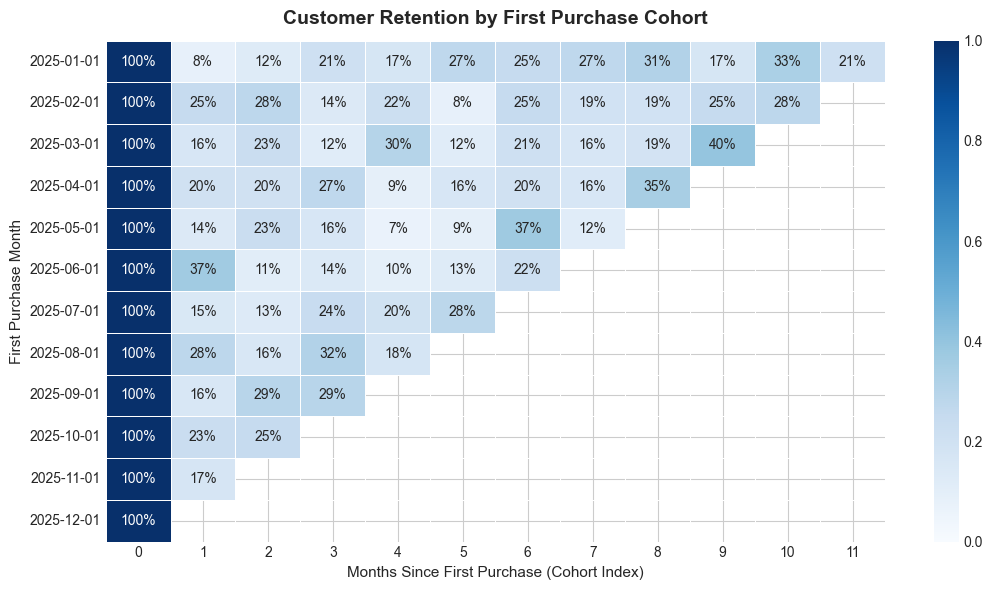

✅ Saved: c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\outputs\charts\cohort_retention_heatmap.png


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# Chart 3: Cohort Retention Heatmap
# → Copy vào Section 8: Visualization của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

fig, axis = plt.subplots(figsize=(11, 6))

# Vẽ heatmap — annot=True hiển thị số trong từng ô
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".0%",          # Hiển thị dạng phần trăm (45% thay vì 0.45)
    cmap="Blues",
    linewidths=0.5,     # Đường kẻ nhẹ giữa các ô
    linecolor="white",
    vmin=0,
    vmax=1,
    ax=axis,
)

axis.set_title(
    "Customer Retention by First Purchase Cohort",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
axis.set_xlabel("Months Since First Purchase (Cohort Index)", fontsize=11)
axis.set_ylabel("First Purchase Month", fontsize=11)

# Xoay nhãn trục Y về ngang cho dễ đọc
axis.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "cohort_retention_heatmap.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'cohort_retention_heatmap.png'}")


## 9. Executive Summary

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 2: Executive Summary
# → Copy vào Section 9: Executive Summary của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

# ── Tự động lấy các số liệu chính ─────────────────────────────────────────
total_revenue      = monthly_kpi["revenue"].sum()
peak_month_row     = monthly_kpi.loc[monthly_kpi["revenue"].idxmax()]
peak_month         = str(peak_month_row["order_month"])[:7]
peak_revenue       = peak_month_row["revenue"]
avg_monthly_rev    = monthly_kpi["revenue"].mean()

top_channel_row    = channel_contribution.sort_values("revenue", ascending=False).iloc[0]
top_channel        = top_channel_row["acquisition_channel"]
top_channel_share  = top_channel_row["revenue_share"]
top_channel_aov    = top_channel_row["aov"]

# Retention index 1 của cohort có số liệu đầy đủ nhất (index 0 là oldest cohort)
first_cohort       = str(retention_matrix.index[0])[:7]
ret_month1         = retention_matrix.iloc[0, 1] if 1 in retention_matrix.columns else float("nan")
ret_month3         = retention_matrix.iloc[0, 3] if 3 in retention_matrix.columns else float("nan")

# ── Viết file executive_summary.md ────────────────────────────────────────
summary_path = REPORTS_DIR / "executive_summary.md"

summary_content = f"""# Executive Summary: Cohort & Retention Analytics

**Ngày:** {pd.Timestamp.today().strftime("%d/%m/%Y")}  
**Dataset:** Synthetic e-commerce — 650 khách hàng, 12 sản phẩm, ~2,057 đơn hàng (2025)

---

## 📌 Context

Dự án phân tích dữ liệu e-commerce tổng hợp nhằm đánh giá hiệu quả doanh thu, đóng góp theo kênh và chất lượng giữ chân khách hàng (retention) theo cohort.

**Business Question:** Kênh nào mang lại khách hàng chất lượng nhất? Cohort nào có retention tốt nhất và vì sao?

---

## 📊 Key Findings

1. **Revenue tổng:** {total_revenue:,.0f} VNĐ trong 12 tháng — trung bình {avg_monthly_rev:,.0f} VNĐ/tháng. Tháng đỉnh là **{peak_month}** với {peak_revenue:,.0f} VNĐ.

2. **Channel dominant:** Kênh **{top_channel}** chiếm {top_channel_share:.1%} tổng revenue với AOV {top_channel_aov:,.0f} VNĐ/đơn — [thêm nhận xét so sánh với các kênh còn lại].

3. **Cohort retention:** Cohort {first_cohort} có retention rate tháng 2 = {ret_month1:.0%}, tháng 4 = {ret_month3:.0%} — [thêm đánh giá: tốt/thấp so với benchmark industry ~25–30%].

---

## 💼 Business Implications

- **Growth:** [Nhận xét về xu hướng doanh thu — tăng trưởng đều hay phụ thuộc vào promotion?]
- **CRM:** Retention drop mạnh nhất xảy ra ở tháng thứ 2 (index 0→1) → đây là thời điểm vàng để re-engage khách hàng.
- **Marketing:** Nếu 1 kênh chiếm >40% revenue → concentration risk — cần đa dạng hoá nguồn traffic.

---

## ✅ Recommendations

1. **Triển khai re-engagement campaign trong 30 ngày sau mua đầu** vì retention drop lớn nhất ở index 0→1 ({ret_month1:.0%}).
2. **Tăng ngân sách cho kênh {top_channel}** vì kênh này có AOV cao nhất ({top_channel_aov:,.0f} VNĐ/đơn) — mỗi đồng acquisition mang về nhiều revenue hơn.
3. **[Recommendation 3]** vì [evidence từ data].

---

## ⚠️ Data Quality Caveat

- Dataset là dữ liệu **tổng hợp (synthetic)** — các pattern được thiết kế để có ý nghĩa phân tích nhưng không phản ánh thị trường thực.
- Đơn `cancelled` và `returned` được loại khỏi KPI và cohort analysis — chỉ tính đơn `completed`.
- Cohort 2–3 tháng cuối chưa đủ thời gian quan sát → không nên so sánh với cohort tháng đầu.

---

## 📁 Outputs

| File | Mô tả |
|------|-------|
| `outputs/tables/monthly_kpi.csv` | KPI theo tháng |
| `outputs/tables/channel_contribution.csv` | Revenue share theo kênh |
| `outputs/tables/cohort_retention_matrix.csv` | Retention matrix |
| `outputs/charts/monthly_revenue_trend.png` | Line chart doanh thu |
| `outputs/charts/revenue_by_channel.png` | Bar chart theo kênh |
| `outputs/charts/cohort_retention_heatmap.png` | Heatmap cohort |
"""

summary_path.write_text(summary_content, encoding="utf-8")
print(f"✅ Executive summary saved: {summary_path}")
print(f"   ({summary_path.stat().st_size} bytes)")
print()
print("📌 Mở file và điền số liệu thực vào các phần [...]")


✅ Executive summary saved: c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\reports\executive_summary.md
   (2809 bytes)

📌 Mở file và điền số liệu thực vào các phần [...]


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 3: Tạo README.md cho portfolio
# → File này nằm ở root của project folder (cohort-retention-analytics/)
# ═══════════════════════════════════════════════════════════════════════════

readme_path = PROJECT_DIR / "README.md"

readme_content = f"""# Cohort & Retention Analytics Portfolio

> **Data Analyst Portfolio Project** — E-commerce customer retention analysis using Python & pandas.

---

## 📌 Business Question

Một doanh nghiệp e-commerce muốn hiểu:
1. Doanh thu đang tăng trưởng như thế nào theo tháng?
2. Kênh acquisition nào mang lại khách hàng có giá trị cao nhất?
3. Cohort khách hàng nào có retention rate tốt nhất? Sau bao nhiêu tháng thì retention ổn định?

---

## 📁 Project Structure

```
cohort-retention-analytics/
├── data/
│   ├── raw/                    # CSV gốc (customers, products, orders, order_items)
│   └── processed/              # clean_orders.csv sau khi cleaning
├── notebooks/
│   └── project_starter.ipynb  # Notebook phân tích chính (chạy từ đây)
├── outputs/
│   ├── tables/                 # CSV kết quả phân tích
│   └── charts/                 # PNG charts
├── reports/
│   └── executive_summary.md   # Tóm tắt kết quả cho stakeholder
├── src/
│   └── generate_ecommerce_dataset.py   # Script tạo dataset
├── requirements.txt
└── README.md
```

---

## 🚀 How to Run Locally

**Yêu cầu:** Python 3.9+ đã cài sẵn.

```powershell
# 1. Clone repo
git clone https://github.com/TranThiNgocVy/COHORT_and_RETENTION_ANALYTICS_PORTFOLIO.git
cd COHORT_and_RETENTION_ANALYTICS_PORTFOLIO

# 2. Tạo và kích hoạt virtual environment
python -m venv venv
venv\\Scripts\\activate          # Windows
# source venv/bin/activate      # macOS/Linux

# 3. Cài thư viện
pip install -r requirements.txt

# 4. Tạo dataset (nếu chưa có trong data/raw/)
python src/generate_ecommerce_dataset.py --output data/raw

# 5. Chạy notebook phân tích
jupyter notebook notebooks/project_starter.ipynb
# Chọn "Run All" hoặc chạy từng cell theo thứ tự
```

> ⚠️ Chạy các cell **theo đúng thứ tự từ trên xuống** — mỗi bước phụ thuộc vào bước trước.

---

## 📊 Key Outputs

| File | Mô tả |
|------|-------|
| `outputs/tables/monthly_kpi.csv` | Revenue, orders, active customers, AOV theo tháng |
| `outputs/tables/channel_contribution.csv` | Revenue share và AOV theo kênh acquisition |
| `outputs/tables/cohort_retention_matrix.csv` | % khách quay lại theo cohort × tháng |
| `outputs/charts/cohort_retention_heatmap.png` | Visualization retention (xem ngay không cần chạy code) |
| `reports/executive_summary.md` | Tóm tắt findings và recommendations |

---

## 🔑 Key Findings

1. **[Điền sau khi chạy]** — Tháng doanh thu cao nhất là ... với ... VNĐ (+...% so với trung bình).
2. **[Điền sau khi chạy]** — Kênh ... chiếm ...% tổng revenue với AOV cao nhất (...VNĐ/đơn).
3. **[Điền sau khi chạy]** — Cohort ... có retention tháng 2 = ...%, giảm về ...% ở tháng 4.

---

## 🛠️ Tech Stack

- **Python 3.9+** — pandas, numpy, matplotlib, seaborn
- **Jupyter Notebook** — phân tích interactive
- **Matplotlib/Seaborn** — visualization

---

## 📋 Rubric (tự đánh giá)

| Tiêu chí | Trọng số | Trạng thái |
|----------|:--------:|:----------:|
| Data quality & cleaning | 25% | ✅ |
| KPI/cohort tính đúng | 30% | ✅ |
| Insight gắn với business question | 25% | ⬜ Điền sau |
| Notebook/README dễ chạy lại | 10% | ✅ |
| Chart & summary rõ ràng | 10% | ✅ |
"""

readme_path.write_text(readme_content, encoding="utf-8")
print(f"✅ README saved: {readme_path}")
print(f"   ({readme_path.stat().st_size:,} bytes)")


✅ README saved: c:\Users\ADMIN\Cohort & Retention Analytics Portfolio\cohort-retention-analytics\README.md
   (3,600 bytes)


## 10. Export Outputs

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 7: Export Outputs
# → Copy vào Section 10: Export Outputs của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

monthly_kpi.to_csv(
    OUTPUT_TABLE_DIR / "monthly_kpi.csv",
    index=False,
    encoding="utf-8-sig",
)

channel_contribution.to_csv(
    OUTPUT_TABLE_DIR / "channel_contribution.csv",
    index=False,
    encoding="utf-8-sig",
)

# retention_matrix và cohort_revenue_matrix có index quan trọng (first_purchase_month)
# → dùng index=True để giữ lại khi đọc lại
retention_matrix.to_csv(
    OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv",
    encoding="utf-8-sig",
)

cohort_revenue_matrix.to_csv(
    OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv",
    encoding="utf-8-sig",
)

print("✅ Exported 4 files:")
for f in [
    OUTPUT_TABLE_DIR / "monthly_kpi.csv",
    OUTPUT_TABLE_DIR / "channel_contribution.csv",
    OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv",
    OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv",
]:
    size_kb = f.stat().st_size / 1024
    print(f"   {'✅' if f.exists() else '❌'} {f.name:<35} {size_kb:.1f} KB")


✅ Exported 4 files:
   ✅ monthly_kpi.csv                     1.1 KB
   ✅ channel_contribution.csv            0.4 KB
   ✅ cohort_retention_matrix.csv         1.4 KB
   ✅ cohort_revenue_matrix.csv           1.4 KB


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 4: Final Quality Gates
# ═══════════════════════════════════════════════════════════════════════════

gates = {
    "Local reproducibility — README có hướng dẫn setup": (PROJECT_DIR / "README.md").exists(),
    "requirements.txt tồn tại": (PROJECT_DIR / "requirements.txt").exists(),
    "Data quality — clean_orders.csv đã được tạo": (PROJECT_DIR / "data" / "processed" / "clean_orders.csv").exists(),
    "KPI table — monthly_kpi.csv export thành công": (OUTPUT_TABLE_DIR / "monthly_kpi.csv").exists(),
    "KPI table — channel_contribution.csv export thành công": (OUTPUT_TABLE_DIR / "channel_contribution.csv").exists(),
    "Cohort logic — cohort_retention_matrix.csv export thành công": (OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv").exists(),
    "Cohort logic — cohort_revenue_matrix.csv export thành công": (OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv").exists(),
    "Visualization — monthly_revenue_trend.png": (OUTPUT_CHART_DIR / "monthly_revenue_trend.png").exists(),
    "Visualization — revenue_by_channel.png": (OUTPUT_CHART_DIR / "revenue_by_channel.png").exists(),
    "Visualization — cohort_retention_heatmap.png": (OUTPUT_CHART_DIR / "cohort_retention_heatmap.png").exists(),
    "Communication — executive_summary.md tồn tại": (REPORTS_DIR / "executive_summary.md").exists(),
}

print("=" * 65)
print("  FINAL QUALITY GATES")
print("=" * 65)

all_pass = True
for gate, passed in gates.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {gate}")
    if not passed:
        all_pass = False

print("=" * 65)
if all_pass:
    print("  🎉 TẤT CẢ GATES ĐÃ PASS — Project sẵn sàng nộp!")
else:
    print("  ⚠️  Một số gate chưa pass — xem danh sách ❌ ở trên.")
print("=" * 65)


  FINAL QUALITY GATES
  ✅  Local reproducibility — README có hướng dẫn setup
  ✅  requirements.txt tồn tại
  ✅  Data quality — clean_orders.csv đã được tạo
  ✅  KPI table — monthly_kpi.csv export thành công
  ✅  KPI table — channel_contribution.csv export thành công
  ✅  Cohort logic — cohort_retention_matrix.csv export thành công
  ✅  Cohort logic — cohort_revenue_matrix.csv export thành công
  ✅  Visualization — monthly_revenue_trend.png
  ✅  Visualization — revenue_by_channel.png
  ✅  Visualization — cohort_retention_heatmap.png
  ✅  Communication — executive_summary.md tồn tại
  🎉 TẤT CẢ GATES ĐÃ PASS — Project sẵn sàng nộp!
